
<p style="font-size:1.25em;"> Ce notebook a pour objectif de fournir rapidement : <br> <strong> Le paramètre d’ordre nématique moyen</strong> <strong>
et les pics de corrélation</strong> à partir d’un dossier contenant des fichiers <strong>H5</strong>. </p>

<span style="font-size: 1.4em; font-weight: 700;"> Fonctionnalités principales</span>
<p style="font-size:1.15em;">

Calcul des intensités moyennes du dossier

Extraction des pics de corrélation

Détermination du paramètre d’ordre sur la valeur de q du premier pic

Importation de l'image de diffusion moyenne,
avec tracé automatique des cercles correspondant aux différents pics

</p>


In [1]:
%matplotlib widget
from utilities_SWING import *
import pandas as pd

**Definition of path, mask file, and output directory (optional)**

In [2]:
#Dossier des H5
h5path='/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/'
#referencefile='path/to/reference/file'  # Si reference
mask = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/mask_pyfai.edf'


**Plot transmission map and grid positions**

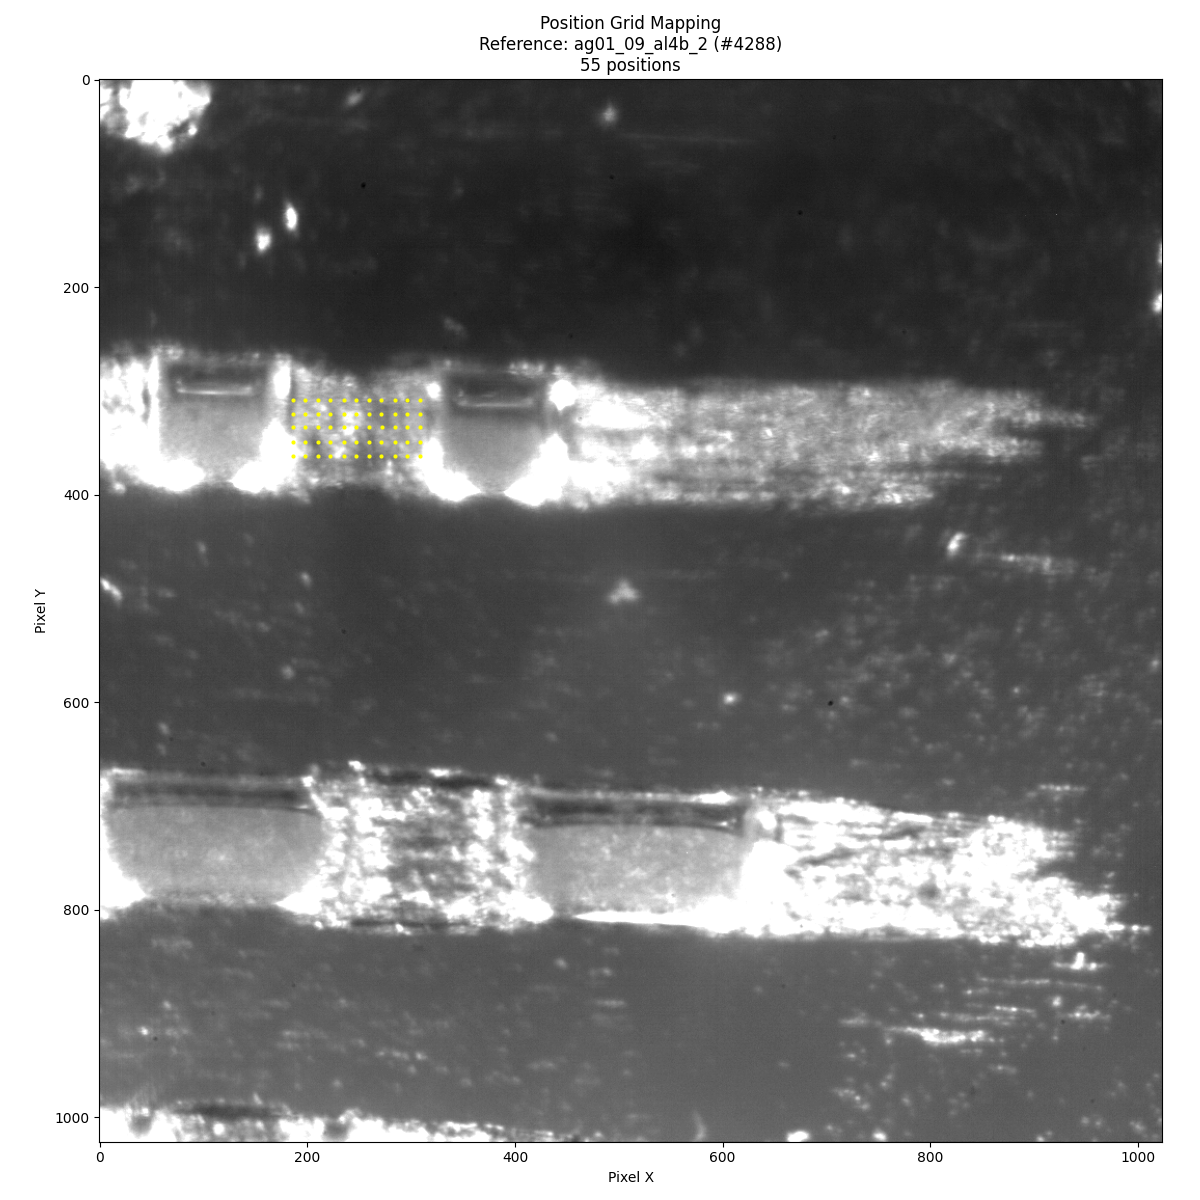

Extracting transmission data:   0%|          | 0/5 [00:00<?, ?it/s]

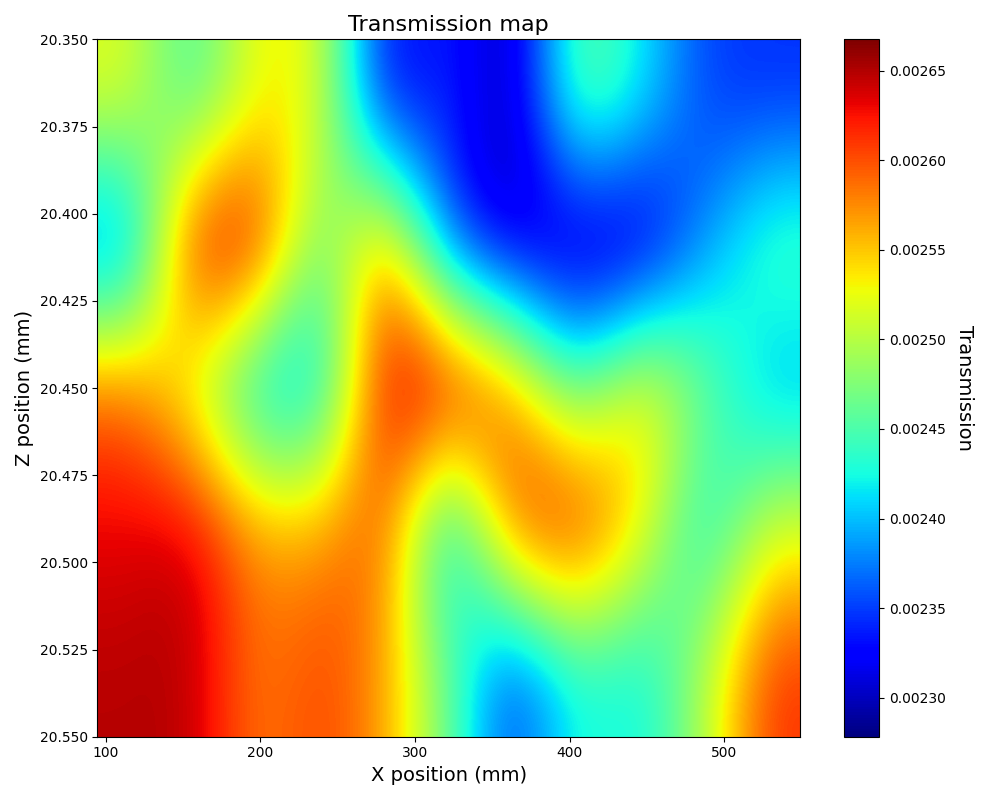

In [3]:
view_position_grid(h5path, prefix='lacroix')
plot_transmission_map(h5path, prefix='lacroix')

**Create SAXSProcessor instance with average intensity**

In [4]:
proc = average_h5_processor(
    h5path,
    mask=mask,
    prefix='lacroix'#,
    #referencefile=referencefile,
    #k=k,
    #autosubtract=True
    )

Processing /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/lacroix_04288_2024-07-22_01-32-09.h5
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Processing /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/lacroix_04289_2024-07-22_01-32-36.h5
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Processing /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/lacroix_04290_2024-07-22_01-33-04.h5
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Processing /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/lacroix_04291_2024-07-22_01-33-32.h5
No motor positions provided. Update fi

**Plot average SAXS image**

✅ SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/saxs_images/ag01_09_al4b_2_Img_4288.png


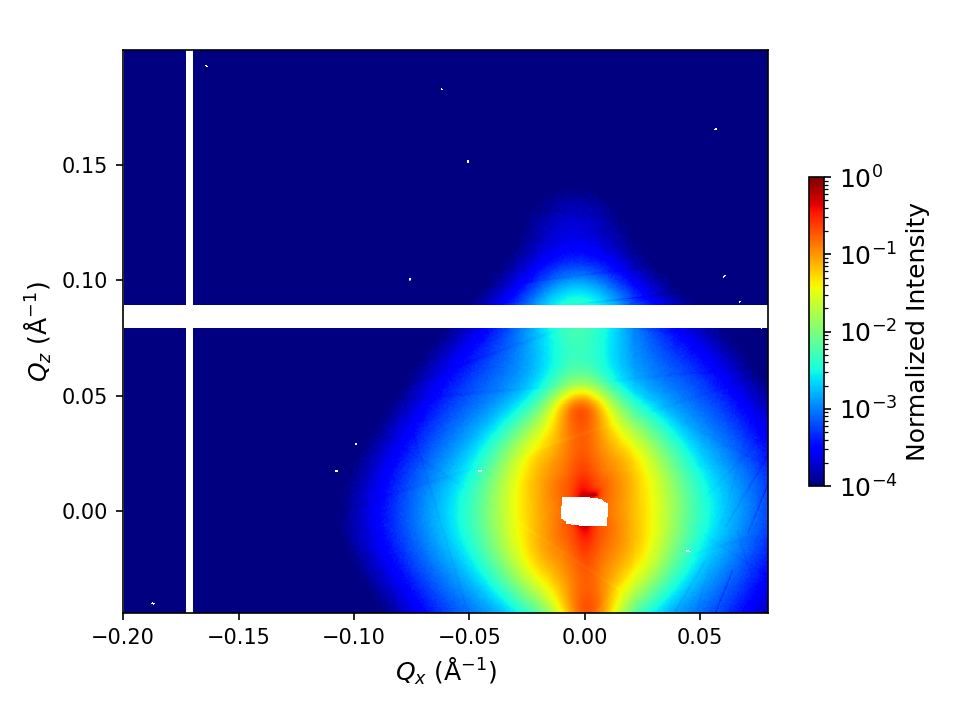

In [5]:
# Use dedicated function to plot average SAXS image
proc.plot2d_vsq()

**Plot and save average radial profile**

From the image above, we can define a q range of interest. This q range can also be determined by plotting the radial profile.
Let's do this first.
Note that the knowledge of this q range is critical for the determination of correlation distances, as it strongly affects results

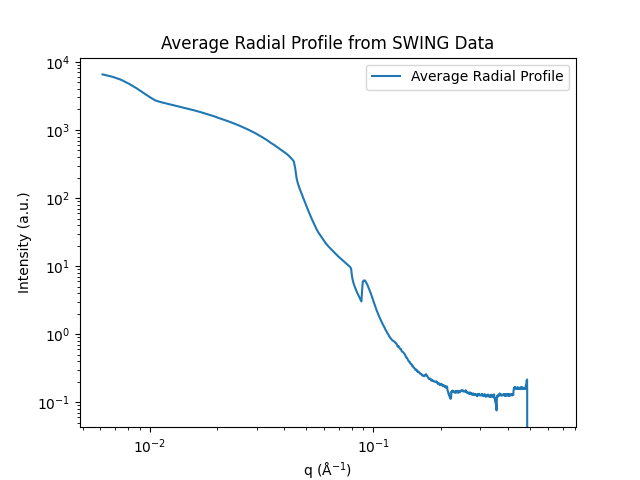

In [6]:
# Plot radial profile for average data
output_dir = os.path.join(proc.path,'average_radial_profile')
q,Ir = proc.extract_radial_profile(azimuth=90, width=360,output_dir=output_dir)

plt.figure()
plt.loglog(q, Ir, label='Average Radial Profile')
plt.xlabel('q (Å$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Average Radial Profile from SWING Data')
plt.legend()

## Determination of correlation peak

**Knowledge of working q range**

The algorithm for the determination of correlation peak requires the knowledge of workin q range (between qmin and qmax). If qmax is not set,the algorithm may focus on the noisy high q range signal. qmax=0.15 may be a good option. Alos qmin should be considered with care. The user is allowed to play with the algorithm parameters until satisfactory results are obtained.

**Hybrid Method**

Here we use a hybrid method using advantages of 2 methods:
- 2nd derivative method is used to identify peak positions (fast and efficient)
- each peak is refined using Split Pseudo Voigt functions to ensure accurate determination of correlation distance (peak identification with this method is not optimum)

There is a large number of arguments in the function. The most relevants are the followings:
- qmin and qmax defining the q window
- nb_peaks defining the number of peaks to search in the specified q window
- method = 'hybrid', 'spv', or 'derivative' depending on the method selected for the computation
- substract_power_law (bool)
- fit_window_width


Playing with these parameters should be enough to obtain satisafctory results. In cas of issues, read dedicated documentation (file parameter_guide.py).


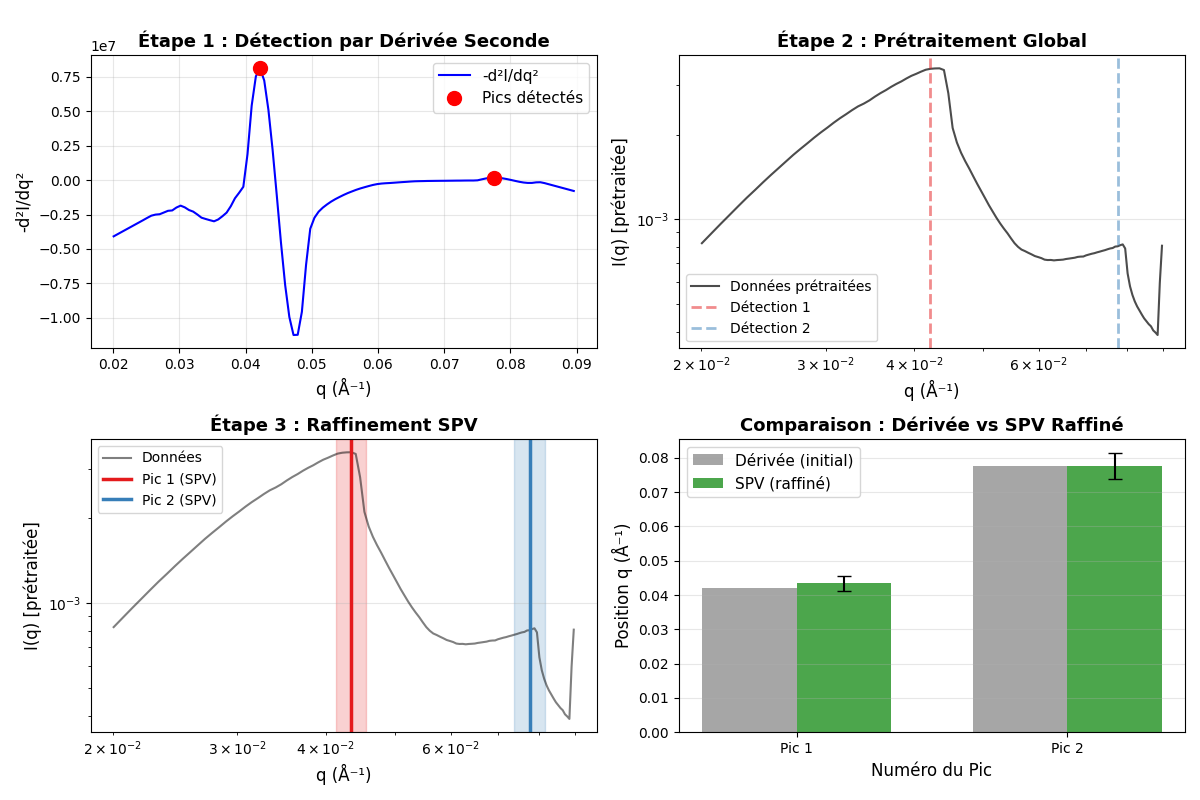


Analyse de Distance de Corrélation
Échantillon : ag01_09_al4b_2
Méthode     : HYBRID
Secteur     : 90° ± 180.0°

2 pic(s) détecté(s) :
  Pic 1:
    Dérivée : q = 0.0422 Å⁻¹
    SPV     : q = 0.0434 ± 0.0022 Å⁻¹ → d = 144.6 ± 7.2 Å
    Δq = 0.0013 Å⁻¹ (3.00%)
    FWHM = 0.0083 Å⁻¹
  Pic 2:
    Dérivée : q = 0.0776 Å⁻¹
    SPV     : q = 0.0776 ± 0.0039 Å⁻¹ → d = 81.0 ± 4.0 Å
    Δq = 0.0000 Å⁻¹ (0.00%)
    FWHM = 0.0676 Å⁻¹

Ordre loi de puissance : m = 3.69


In [7]:
distances, err, results = compute_average_correlation_distances(
    proc,
    nb_peaks=2,
    azimuth=90,
    width=360,
    qmin=0.02,
    qmax=0.09,
    method='hybrid',
    # Détection initiale (dérivée seconde)
    window_length=15,
    polyorder=3,
    prominence=0.5,
    distance_pts=20,
    # Raffinement SPV
    subtract_power_law=True,
    power_law_method='cancel',
    power_law_order=None,
    power_law_range=(2.5, 5.0),
    smooth=False,
    smooth_sigma=2,
    fit_window_width=0.5, 
    verbose=False,
    plot=True)


## Nematic order parameter

**Selection of working qvalue**

We select the first pealk returned by the calculation of correlation distances

In [8]:
qvalues = results['q_peaks']#[0]
#print(f'The selected q-value is: {qvalue:.3f} Å⁻¹')

**Form factor parameters**

Used for nematic order calculation

In [9]:
# To be completed with actual values (data usually extracted from TEM images)
L = 1000
radius = 100
radius_pd = 0.2
L_pd=1.7  # polydispersity on length is huge!

**Nematic Order Calculation**

It is computed for each peak determined above


Azimuthal profile completeness check:
  Status: COMPLETE
  Profile is complete (no NaN/zero values)
  → Mirror symmetry: DISABLED
Main nanorod orientation is 2.3407939115092518

Computing cylinder form factor...


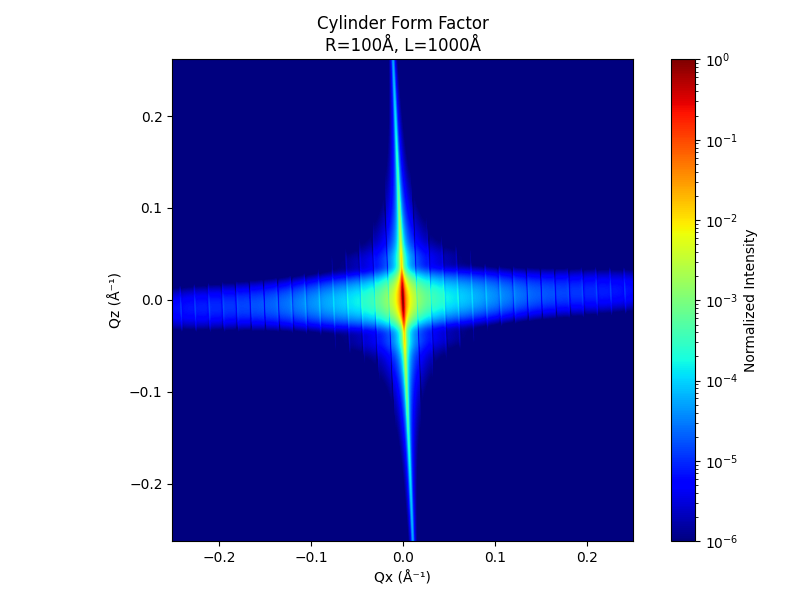


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/azimuthal_profiles/ag01_09_al4b_2_B=0_Img4288_nematic_determination.png

Fitting results:
x0: 88.62998356619346
S: 0.9715981476191264
R2: 0.958570752860983

Azimuthal profile completeness check:
  Status: INCOMPLETE
  Too many invalid points (30.4% are NaN/0, threshold=10.0%)
  → Mirror symmetry: ENABLED
Main nanorod orientation is -0.3583051975228386

Computing cylinder form factor...


/home-local/ratel-ra/anaconda3_c/envs/py311/lib/python3.11/site-packages/pyFAI/azimuthalIntegrator.py:1670: RuntimeWarning: invalid value encountered in divide
  intensity = sum_signal / sum_normalization


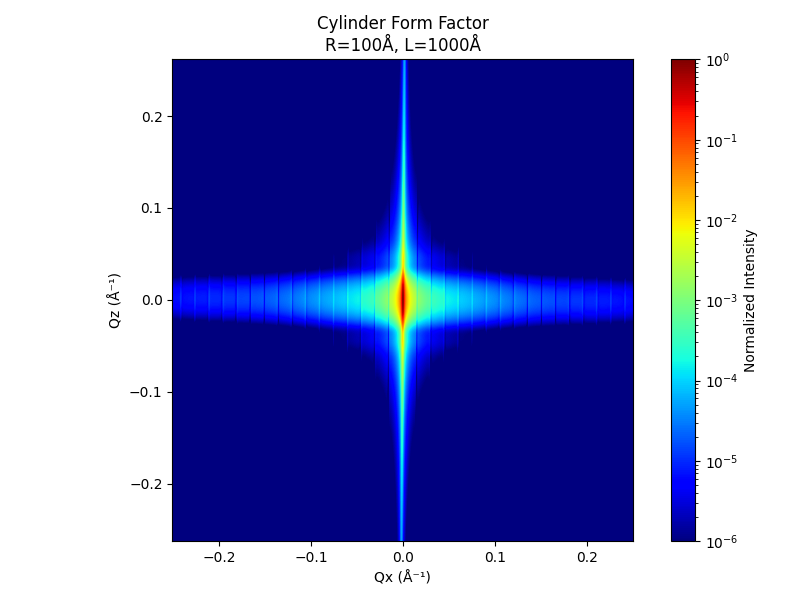


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/azimuthal_profiles/ag01_09_al4b_2_B=0_Img4288_nematic_determination.png

Fitting results:
x0: -89.22181118451842
S: 0.9564336971258218
R2: 0.8568549172919276


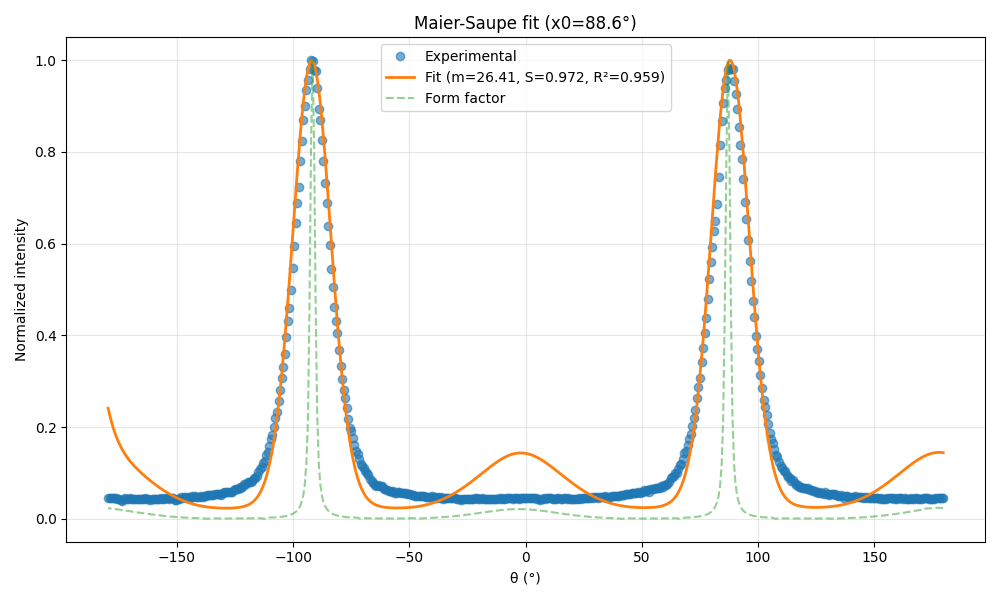

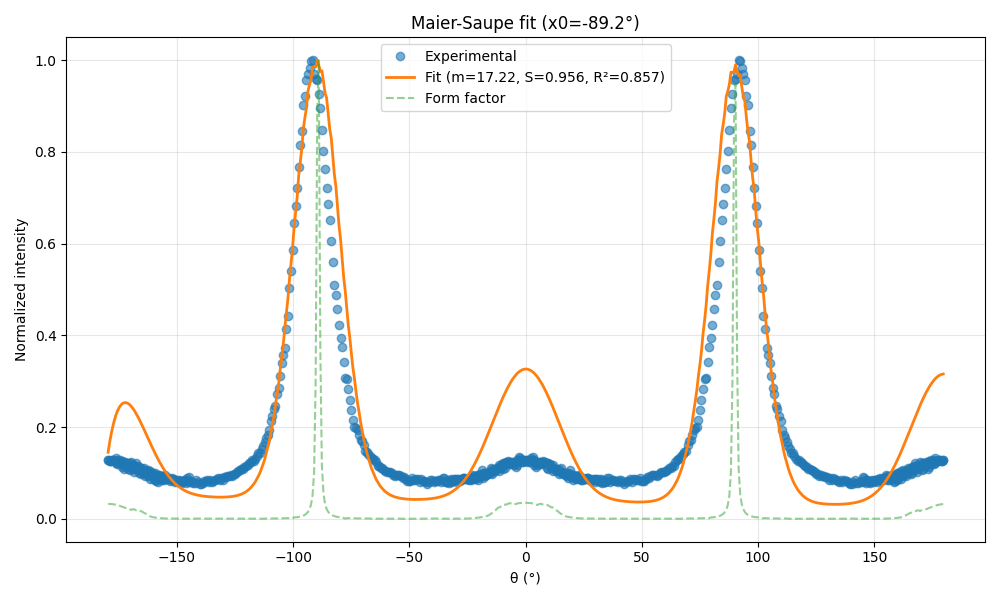

In [10]:
threshold = 0.01
plot = True
apply_mirror = False 
verbose = False

S_array = np.zeros(len(qvalues))
for i, qvalue in enumerate(qvalues):
    S, mean_angle, dict = compute_nematic_parameter(
        processor = proc,
        qvalue = qvalue,
        threshold = threshold,
        radius = radius,
        L = L,
        radius_pd = radius_pd,
        L_pd= L_pd,
        plot = plot,
        verbose = True
        )
    S_array[i] = S

## Store results in a dict or csv???

**Metadata**

Dans les exemple de data SWING à notre disposition, on ne fait pas varier le champ magnétique.

J'ai ajouté à la classe h5File_Swing une méthode pour extraire la valeur de B de l'attribut samplename.

Lors de l'acquisition des data, au moment de remplir le champ de référence échantillon, il vous faudra ajouter le champ B à la réf échantillon sous un format de style **'*_xxxmT*'**. 
 
 A la lecture du fichier h5, on aura alors accès à la valeur de B via l'attribut B de SAXSProcessor.

**Stockage csv**

J'ai ici indiqué un chemin vers un fichier csv fictif. A modifier


In [11]:
# save data in dictionary

results={
    'samplename': proc.samplename,
    'B (mT)': proc.B,
    'distance (A)': distances, # array of distances
    'distance_error (A)': err, # array of errors
    'nematic_parameter': S_array # array of nematic order parameters
}

# add dictionary to existing csv or create new one
csv_file = os.path.join(proc.path,'analysis_results.csv')  # A MODIFIER, je ne sais poas où vous allez stocker ce fichier.
if os.path.exists(csv_file):
    df_existing = pd.read_csv(csv_file)
    df_new = pd.DataFrame([results])
    df_combined = pd.concat([df_existing, df_new], ignore_index=True)
    df_combined.to_csv(csv_file, index=False)
    # visualize added line
    print(df_new)
else:
    df = pd.DataFrame([results])
    df.to_csv(csv_file, index=False)


       samplename  B (mT)                           distance (A)  \
0  ag01_09_al4b_2       0  [144.6386420060107, 80.9952641928703]   

                         distance_error (A)  \
0  [7.2319321003005355, 4.0497632096435145]   

                          nematic_parameter  
0  [0.9715981476191264, 0.9564336971258218]  


## Batch function

All these steps have been wrapped up in a single function "global_analyis", that could be further used for batch analysis. 
This function takes a total of 31 arguments, decomposed as follows:
- 1 arg for csv_file path where results are stored (csv_file)
- 2 args to define the list of files to be analyzed (h5path, prefix='lacroix')
- 4 args to initialize SAXSProcessor instance (mask, referencefile=None, k=1, autosubstract=True)
- 17 args(!) to initialize the hybrid method for correlation distance calculation. (mandatory ones: nb_peaks, qmin, qmax -- other parameters can keep their default value as a start)
- 5 args for nematic order calculation (radius, L, radius_pd, L_pd, threshold) - mostly used for form factor calculation
- 2 args for output (plot, verbose)

There are 10 mandatory arguments:
- csv_file: path to file where results are appended
- h5path: path to data directory
- mask: path to mask file (pyfai edf format)
- nb_peaks: number of peaks for correlation distance determination
- qmin (=0.01) - qmax (=0.15): fitting window for correlation distance determination
- Form factor parameters (radius, L, radius_pd, L_pd)

Processing /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/lacroix_04288_2024-07-22_01-32-09.h5
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Processing /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/lacroix_04289_2024-07-22_01-32-36.h5
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Processing /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/lacroix_04290_2024-07-22_01-33-04.h5
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Processing /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/lacroix_04291_2024-07-22_01-33-32.h5
No motor positions provided. Update fi

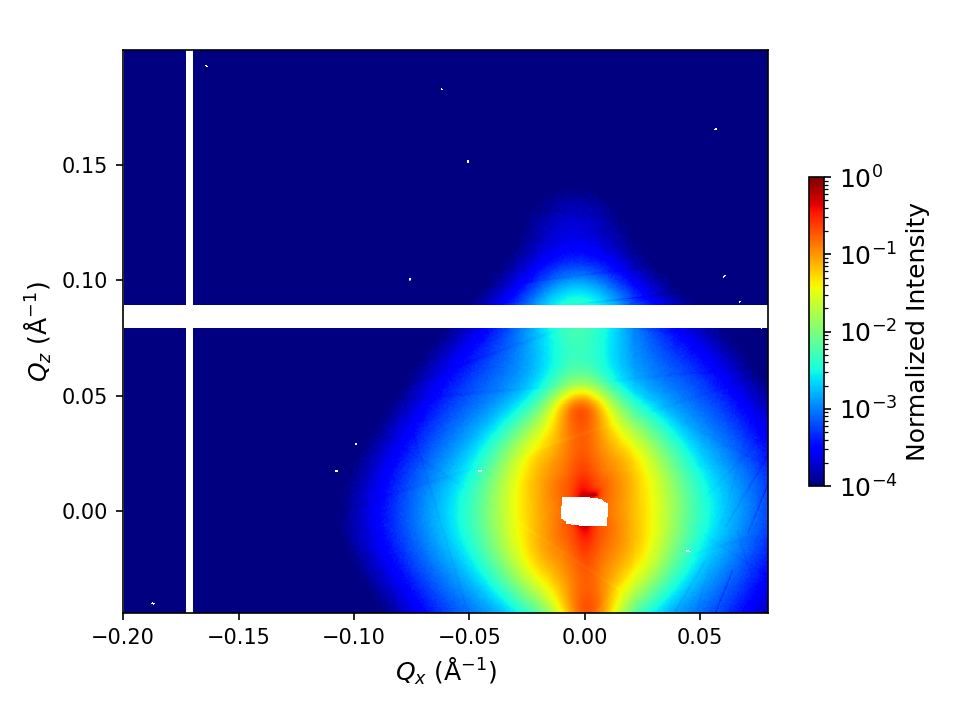


Analyse de Distance de Corrélation
Échantillon : ag01_09_al4b_2
Méthode     : HYBRID
Secteur     : 90° ± 15.0°

1 pic(s) détecté(s) :
  Pic 1:
    Dérivée : q = 0.0428 Å⁻¹
    SPV     : q = 0.0434 ± 0.0022 Å⁻¹ → d = 144.6 ± 7.2 Å
    Δq = 0.0006 Å⁻¹ (1.48%)
    FWHM = 0.0077 Å⁻¹

Ordre loi de puissance : m = 3.20

Azimuthal profile completeness check:
  Status: INCOMPLETE
  Found 2 gap(s) with invalid data:
    Gap 1: between χ=-91.0° and χ=-90.3° (1 points)
    Gap 2: between χ=89.7° and χ=90.3° (1 points)
  → Mirror symmetry: ENABLED
Main nanorod orientation is 2.3407939115092518

Computing cylinder form factor...


/home-local/ratel-ra/anaconda3_c/envs/py311/lib/python3.11/site-packages/pyFAI/azimuthalIntegrator.py:1670: RuntimeWarning: invalid value encountered in divide
  intensity = sum_signal / sum_normalization



Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q

Fitting results:
x0: 89.3875301301801
S: 0.9577124029076391
R2: 0.8479061280182626
The following line        samplename  B (mT)           q_peak (A⁻¹)         distance (A)  \
0  ag01_09_al4b_2       0  [0.04344057175895275]  [144.6386420060107]   

     distance_error (A)  mean_orientation (°)     nematic_parameter  
0  [7.2319321003005355]  [2.3407939115092518]  [0.9577124029076391]   has been added to file /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/analysis_results.csv
✓ Global analysis results saved to: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/analysis_results.csv


In [13]:
# Alternatively, use global_analysis function to perform all steps at once
results = global_analysis(
    csv_file=csv_file,
    h5path=h5path,
    mask=mask,
    nb_peaks=2,
    qmin=0.02,
    qmax=0.09,
    azimuth=90,
    width=30,
    method='hybrid',
    radius=radius,
    L=L,
    radius_pd=radius_pd,
    L_pd=L_pd,
    plot=False,
    verbose=False)